In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df=pd.read_csv("crimes_against_women_2001-2014.csv")
df.head(10)

,Unnamed: 0,STATE/UT,DISTRICT,Year,Rape,Kidnapping and Abduction,Dowry Deaths,Assault on women with intent to outrage her modesty,Insult to modesty of Women,Cruelty by Husband or his Relatives,Importation of Girls
0,0,ANDHRA PRADESH,ADILABAD,2001,50,30,16,149,34,175,0
1,1,ANDHRA PRADESH,ANANTAPUR,2001,23,30,7,118,24,154,0
2,2,ANDHRA PRADESH,CHITTOOR,2001,27,34,14,112,83,186,0
3,3,ANDHRA PRADESH,CUDDAPAH,2001,20,20,17,126,38,57,0
4,4,ANDHRA PRADESH,EAST GODAVARI,2001,23,26,12,109,58,247,0
5,5,ANDHRA PRADESH,GUNTAKAL RLY.,2001,0,0,0,1,0,0,0
6,6,ANDHRA PRADESH,GUNTUR,2001,54,51,7,139,129,378,0
7,7,ANDHRA PRADESH,HYDERABAD CITY,2001,37,39,24,118,27,746,0
8,8,ANDHRA PRADESH,KARIMNAGAR,2001,56,49,62,414,81,224,0
9,9,ANDHRA PRADESH,KHAMMAM,2001,47,30,17,180,336,172,0


In [9]:
df=pd.read_csv("crimes_against_women_2001-2014.csv")
df.head(5)

,Unnamed: 0,STATE/UT,DISTRICT,Year,Rape,Kidnapping and Abduction,Dowry Deaths,Assault on women with intent to outrage her modesty,Insult to modesty of Women,Cruelty by Husband or his Relatives,Importation of Girls
0,0,ANDHRA PRADESH,ADILABAD,2001,50,30,16,149,34,175,0
1,1,ANDHRA PRADESH,ANANTAPUR,2001,23,30,7,118,24,154,0
2,2,ANDHRA PRADESH,CHITTOOR,2001,27,34,14,112,83,186,0
3,3,ANDHRA PRADESH,CUDDAPAH,2001,20,20,17,126,38,57,0
4,4,ANDHRA PRADESH,EAST GODAVARI,2001,23,26,12,109,58,247,0


In [11]:
states=df['STATE/UT'].unique()
print("Number of states/territories with duplicates: ", len(states))
print(states)

Number of states/territories with duplicates:  72
['ANDHRA PRADESH' 'ARUNACHAL PRADESH' 'ASSAM' 'BIHAR' 'CHHATTISGARH' 'GOA'
 'GUJARAT' 'HARYANA' 'HIMACHAL PRADESH' 'JAMMU & KASHMIR' 'JHARKHAND'
 'KARNATAKA' 'KERALA' 'MADHYA PRADESH' 'MAHARASHTRA' 'MANIPUR' 'MEGHALAYA'
 'MIZORAM' 'NAGALAND' 'ODISHA' 'PUNJAB' 'RAJASTHAN' 'SIKKIM' 'TAMIL NADU'
 'TRIPURA' 'UTTAR PRADESH' 'UTTARAKHAND' 'WEST BENGAL' 'A & N ISLANDS'
 'CHANDIGARH' 'D & N HAVELI' 'DAMAN & DIU' 'DELHI' 'LAKSHADWEEP'
 'PUDUCHERRY' 'Andhra Pradesh' 'Arunachal Pradesh' 'Assam' 'Bihar'
 'Chhattisgarh' 'Goa' 'Gujarat' 'Haryana' 'Himachal Pradesh'
 'Jammu & Kashmir' 'Jharkhand' 'Karnataka' 'Kerala' 'Madhya Pradesh'
 'Maharashtra' 'Manipur' 'Meghalaya' 'Mizoram' 'Nagaland' 'Odisha'
 'Punjab' 'Rajasthan' 'Sikkim' 'Tamil Nadu' 'Tripura' 'Uttar Pradesh'
 'Uttarakhand' 'West Bengal' 'A&N Islands' 'Chandigarh' 'D&N Haveli'
 'Daman & Diu' 'Delhi UT' 'Lakshadweep' 'Puducherry' 'Telangana'
 'A & N Islands']


In [136]:
df["STATE/UT"]=df.apply(lambda row:row['STATE/UT'].replace(" ","").lower(),axis=1)
df['STATE/UT'].replace("delhiut",'delhi',inplace=True)

In [25]:
df['STATE/UT'] = df['STATE/UT'].str.replace(" ", "").str.lower()
df.loc[df['STATE/UT'] == "delhint", 'STATE/UT'] = 'delhi'
df.loc[df['STATE/UT'] == "delhiut", 'STATE/UT'] = 'delhi'

In [37]:
states=df['STATE/UT'].unique()
print("Number of states/territories without duplicates: ", len(states))
print(states)

Number of states/territories without duplicates:  36
['andhrapradesh' 'arunachalpradesh' 'assam' 'bihar' 'chhattisgarh' 'goa'
 'gujarat' 'haryana' 'himachalpradesh' 'jammu&kashmir' 'jharkhand'
 'karnataka' 'kerala' 'madhyapradesh' 'maharashtra' 'manipur' 'meghalaya'
 'mizoram' 'nagaland' 'odisha' 'punjab' 'rajasthan' 'sikkim' 'tamilnadu'
 'tripura' 'uttarpradesh' 'uttarakhand' 'westbengal' 'a&nislands'
 'chandigarh' 'd&nhaveli' 'daman&diu' 'delhi' 'lakshadweep' 'puducherry'
 'telangana']


In [43]:
df.isnull().sum()

Unnamed: 0                                             0
STATE/UT                                               0
DISTRICT                                               0
Year                                                   0
Rape                                                   0
Kidnapping and Abduction                               0
Dowry Deaths                                           0
Assault on women with intent to outrage her modesty    0
Insult to modesty of Women                             0
Cruelty by Husband or his Relatives                    0
Importation of Girls                                   0
dtype: int64

In [45]:
#Dropping "Unnamed" Column
df=df.drop(['Unnamed: 0'],axis=1)

In [47]:
df['total_crimes']=(df['Rape']+df['Kidnapping and Abduction']+df['Dowry Deaths']+
                       df['Assault on women with intent to outrage her modesty']+
                       df['Insult to modesty of Women']+df['Cruelty by Husband or his Relatives']+
                       df['Importation of Girls'])

In [49]:
def with_hue(data,feature,ax):
    
    #Numnber of categories
    num_of_cat=len([x for x in data[feature].unique() if x==x])
    
    bars=ax.patches
    
    for ind in range(num_of_cat):
        ##     Get every hue bar
        ##     ex. 8 X categories, 4 hues =>
        ##    [0, 8, 16, 24] are hue bars for 1st X category
        hueBars=bars[ind:][::num_of_cat] 
        # Get the total height (for percentages)
        total=sum([x.get_height() for x in hueBars])
        #Printing percentages on bar
        for bar in hueBars:
            percentage='{:.1f}%'.format(100 * bar.get_height()/total)
            ax.text(bar.get_x()+bar.get_width()/2.0,
                   bar.get_height(),
                   percentage,
                    ha="center",va="bottom",fontweight='bold',fontsize=10)
    

    
def without_hue(data,feature,ax):
    
    total=float(len(data))
    bars_plot=ax.patches
    
    for bars in bars_plot:
        percentage = '{:.1f}%'.format(100 * bars.get_height()/total)
        x = bars.get_x() + bars.get_width()/2.0
        y = bars.get_height()
        ax.text(x, y+2,y,ha='center',fontweight='bold',fontsize=7)


In [57]:
value_count=list(df["STATE/UT"].value_counts())
print(" Value counts of STATES/UT")
print(value_count)

 Value counts of STATES/UT
[1032, 739, 645, 632, 552, 541, 504, 472, 461, 425, 424, 384, 372, 370, 366, 324, 318, 276, 234, 222, 208, 196, 162, 147, 129, 120, 87, 71, 44, 43, 42, 37, 28, 28, 28, 14]


In [61]:
#Analysis on year 

In [63]:
crimes=['Rape','Kidnapping and Abduction','Dowry Deaths',
        'Assault on women with intent to outrage her modesty',
        'Insult to modesty of Women','Cruelty by Husband or his Relatives',
        'Importation of Girls','total_crimes']

df1=pd.DataFrame()
for i in crimes:
    df_crimes=df.groupby(['Year'])[i].sum()
    df1[i]=df_crimes
df1

,Rape,Kidnapping and Abduction,Dowry Deaths,Assault on women with intent to outrage her modesty,Insult to modesty of Women,Cruelty by Husband or his Relatives,Importation of Girls,total_crimes
Year,,,,,,,,
2001,32150,29290,13702,68248,19492,98340,228,261450
2002,32746,29012,13644,67886,20310,98474,152,262224
2003,31694,26592,12416,65878,24650,101406,92,262728
2004,36466,31156,14052,69134,20002,116242,178,287230
2005,36718,31500,13574,68350,19968,116638,298,287046
2006,38696,34828,15236,73234,19932,126256,134,308316
2007,41474,40832,16186,77468,21900,151860,122,349842
2008,42934,45878,16344,80826,24428,162688,134,373232
2009,42794,51482,16766,77422,22018,179092,96,389670


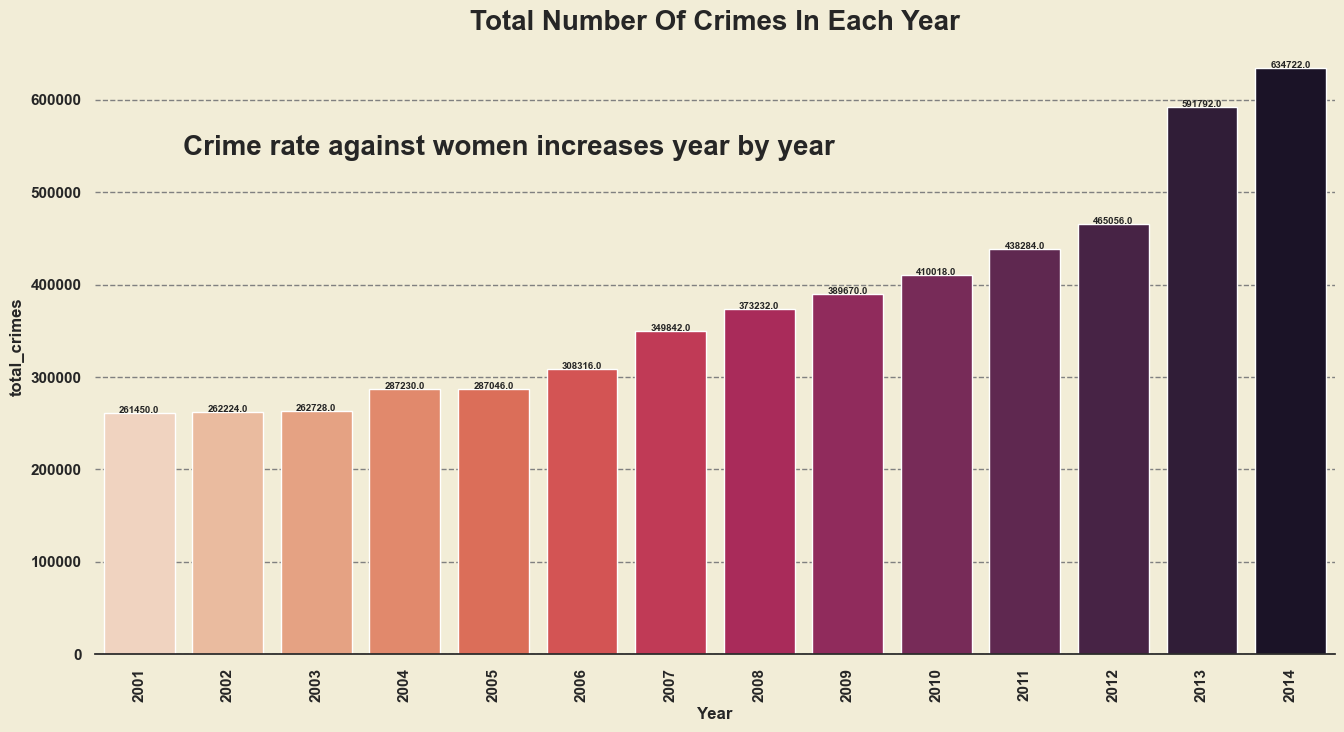

In [138]:
sns.set_theme(style='white',context='notebook')

fig=plt.figure(figsize=(16,8))

ax=plt.axes()
ax.set_facecolor("#F2EDD7FF")
fig.patch.set_facecolor("#F2EDD7FF")

ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(linestyle="--",axis="y",color='gray')

lower_year=2001
upper_year=2014
arr=[]
for i in range(lower_year,upper_year+1):
    arr.append(i)
arr=np.array(arr)
a=sns.barplot(data=df1,x=arr,y='total_crimes',palette='rocket_r')
ax.set_xticklabels(ax.get_xticklabels(),rotation = 90)
plt.text(0.5,540000,"Crime rate against women increases year by year",fontweight='bold',fontsize=20)
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
plt.xlabel("Year",fontweight='bold')
plt.ylabel("total_crimes",fontweight='bold')
plt.title("Total Number Of Crimes In Each Year",fontweight='bold',fontsize=20)
without_hue(df1,'total_crimes',a)
plt.show()

In [69]:
def plotting_cat_features(nrows,ncols,cat_columns):
    
    f,ax=plt.subplots(nrows=nrows,ncols=ncols,figsize=(16,25))
    f.patch.set_facecolor('#F2EDD7FF')
    #Setting background and foreground color
    for i in range(0,nrows):
        for j in range(0,ncols):
            ax[i][j].set_facecolor('#F2EDD7FF')

    #Plotting count plot 
    for i in range(0,nrows):
        for j in range(0,ncols):
            a1=sns.barplot(data=df1,x=df1.index,y=cat_columns[i*(nrows-2)+j],palette='rocket',ax=ax[i][j])
            without_hue(df,cat_columns[i-1],a1)
            #Dealing with spines
            ax[i][j].spines['top'].set_visible(False)
            ax[i][j].spines['right'].set_visible(False)
            ax[i][j].spines['left'].set_visible(False)
            ax[i][j].grid(linestyle="--",axis='y',color='gray')
            
        
    


C:\Users\akshi\AppData\Local\Temp\ipykernel_20704\3756375092.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  a1=sns.barplot(data=df1,x=df1.index,y=cat_columns[i*(nrows-2)+j],palette='rocket',ax=ax[i][j])
C:\Users\akshi\AppData\Local\Temp\ipykernel_20704\3756375092.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  a1=sns.barplot(data=df1,x=df1.index,y=cat_columns[i*(nrows-2)+j],palette='rocket',ax=ax[i][j])
C:\Users\akshi\AppData\Local\Temp\ipykernel_20704\3756375092.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  a1=sns.barplot(data=df1,x=df1.index,y=cat_columns[i

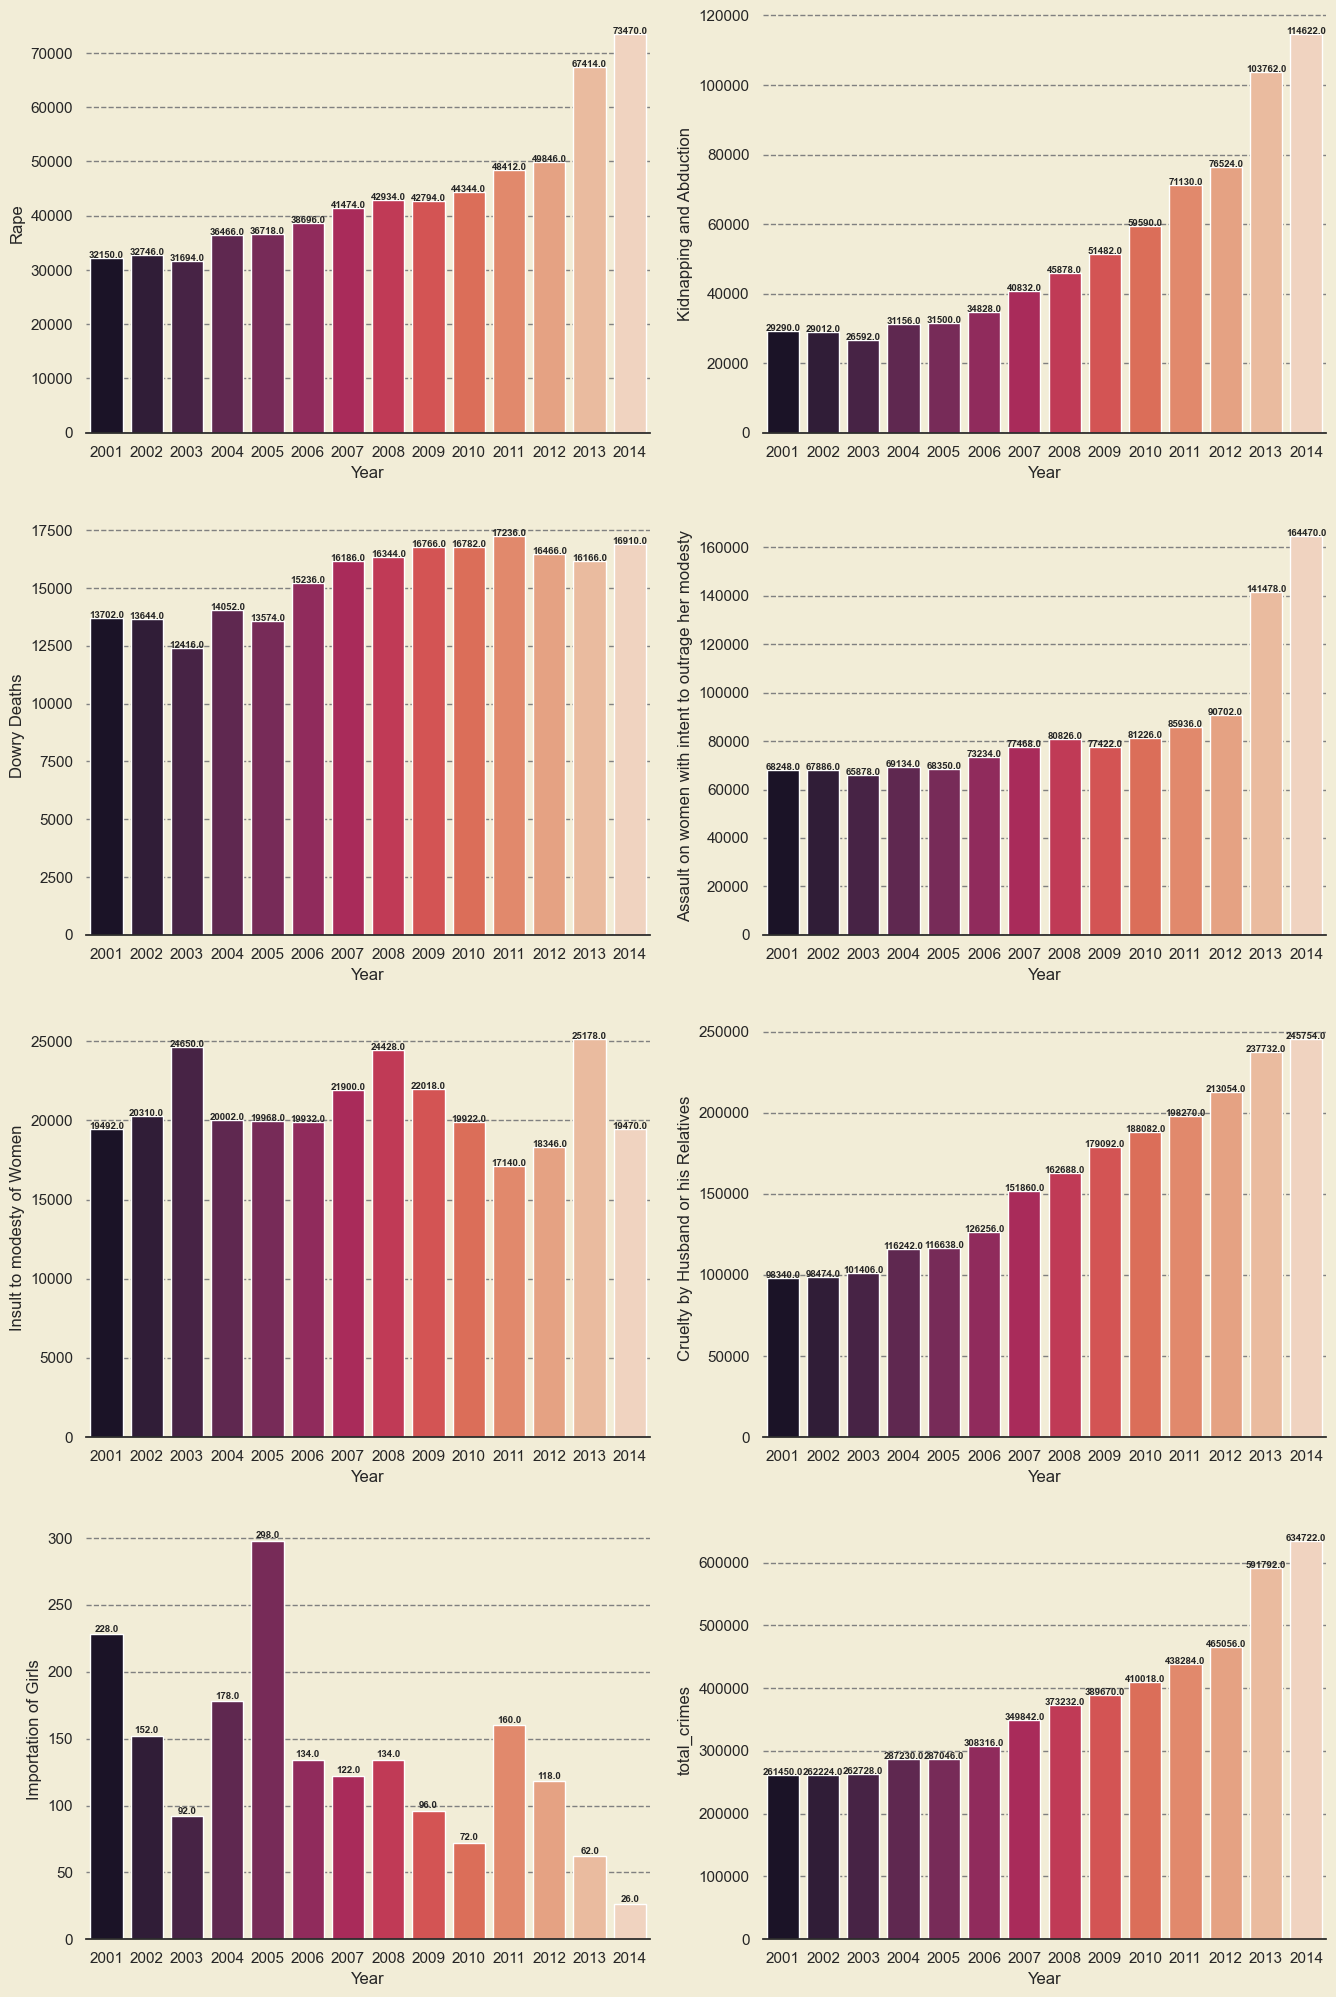

In [73]:
plotting_cat_features(4,2,crimes)

In [ ]:
# CRIME RATE INCREMENT YEAR BY YEAR

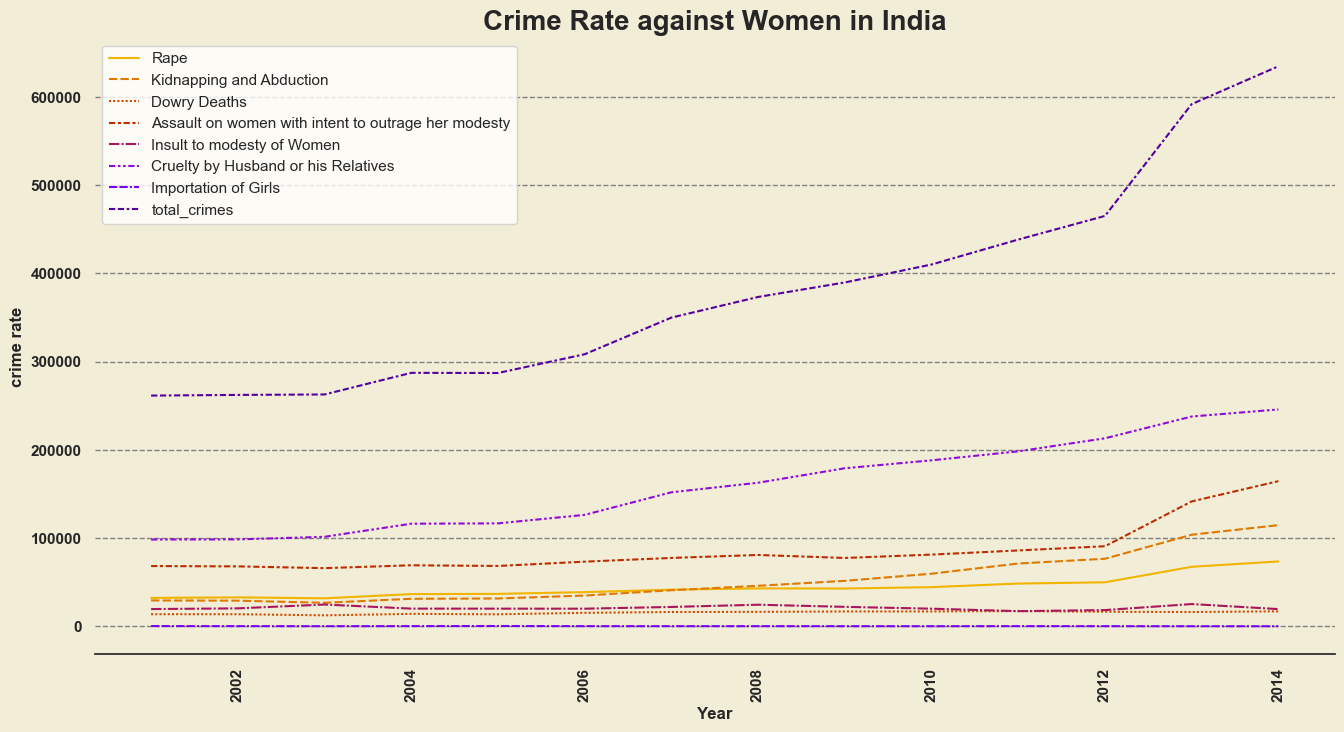

In [92]:
sns.set_theme(style='white',context='notebook')

fig=plt.figure(figsize=(16,8))

ax=plt.axes()
ax.set_facecolor("#F2EDD7FF")
fig.patch.set_facecolor("#F2EDD7FF")

ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(linestyle="--",axis="y",color='gray')

lower_year=2001
upper_year=2014
arr=[]
for i in range(lower_year,upper_year+1):
    arr.append(i)
arr=np.array(arr)

a=sns.lineplot(data=df1,palette='gnuplot_r',linestyle="dashed")#,x=arr,y='Rape',hue_order=crimes,palette='rocket_r')

ax.set_xticklabels(ax.get_xticklabels(),rotation = 90)
#plt.text(0.5,540000,"Crime rate against women increases year by year",fontweight='bold',fontsize=20)
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
plt.xlabel("Year",fontweight='bold')
plt.ylabel("crime rate",fontweight='bold')
plt.title("Crime Rate against Women in India",fontweight='bold',fontsize=20)
plt.show()

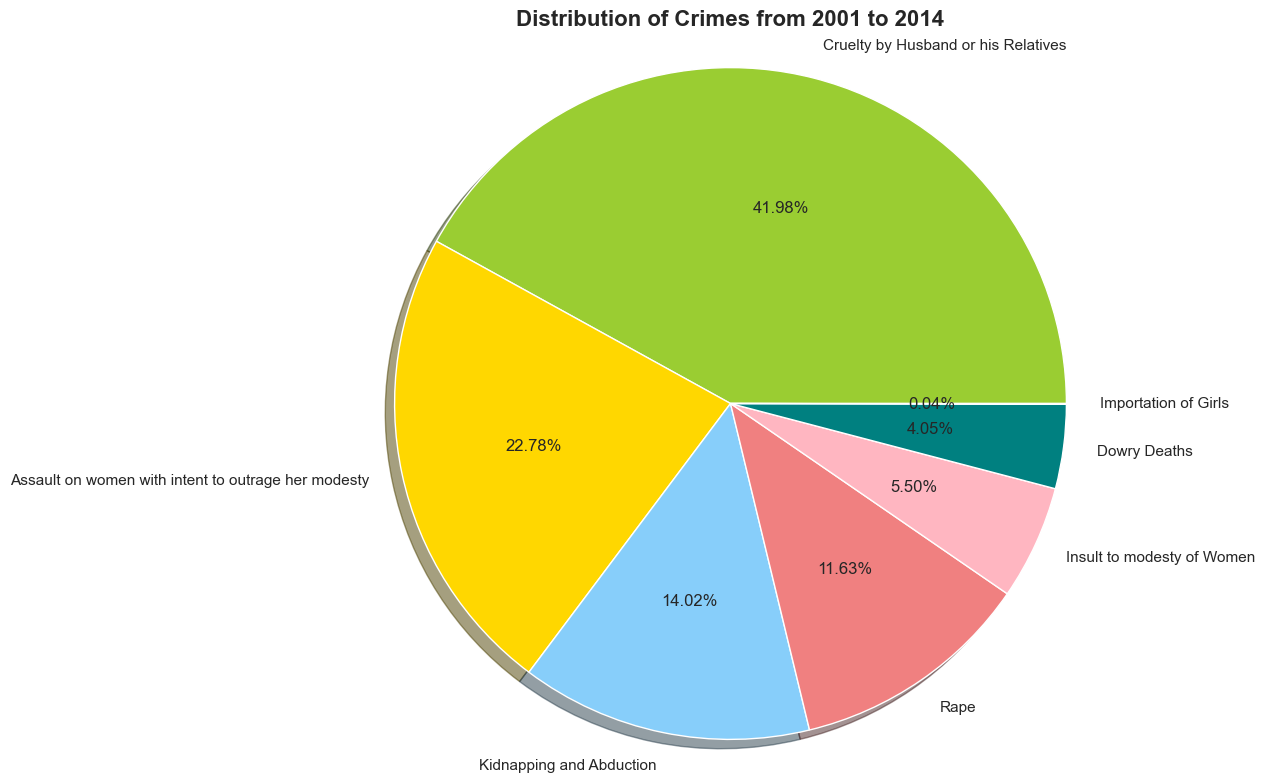

In [88]:
# Modern pandas-compatible solution
crimes = ['Rape', 'Kidnapping and Abduction', 'Dowry Deaths',
          'Assault on women with intent to outrage her modesty',
          'Insult to modesty of Women', 'Cruelty by Husband or his Relatives',
          'Importation of Girls']

# Create DataFrame in one operation
df_top_crimes = pd.DataFrame({
    'crimes': crimes,
    'total': [df[crime].sum() for crime in crimes]
}).sort_values('total', ascending=False)

# Visualization
plt.figure(figsize=(12,8))
plt.pie(df_top_crimes['total'], 
        labels=df_top_crimes['crimes'],
        autopct='%1.2f%%',
        colors=['yellowgreen', 'gold', 'lightskyblue', 'lightcoral', 'lightpink', 'teal', 'green'],
        shadow=True)

plt.title("Distribution of Crimes from 2001 to 2014", fontweight='bold', fontsize=16)
plt.axis('equal')
plt.tight_layout()
plt.show()

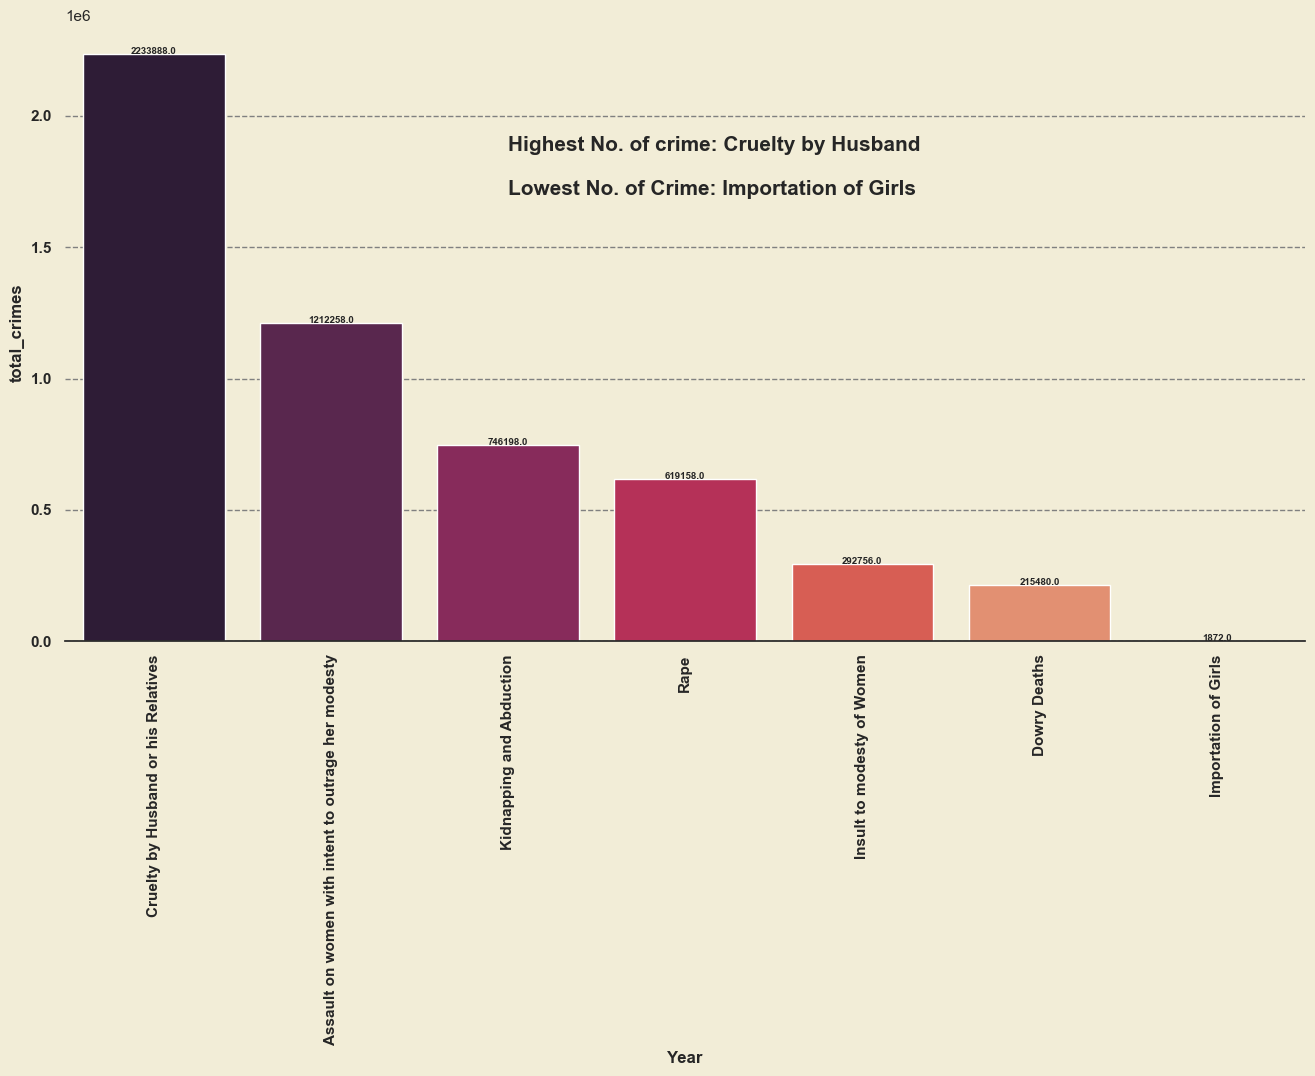

In [94]:
sns.set_theme(style='white',context='notebook')

fig=plt.figure(figsize=(16,8))

ax=plt.axes()
ax.set_facecolor("#F2EDD7FF")
fig.patch.set_facecolor("#F2EDD7FF")

ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(linestyle="--",axis="y",color='gray')

a=sns.barplot(data=df_top_crimes,y='total',x='crimes',palette='rocket')
ax.set_xticklabels(ax.get_xticklabels(),rotation =90)
#plt.text(0.5,540000,"Crime rate against women increases year by year",fontweight='bold',fontsize=20)
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
plt.xlabel("Year",fontweight='bold')
plt.ylabel("total_crimes",fontweight='bold')
plt.text(2,1700000, "Highest No. of crime: Cruelty by Husband\n\nLowest No. of Crime: Importation of Girls",fontweight='bold',fontsize=15)
without_hue(df_top_crimes,'total',a)
plt.show()

In [96]:
#Comparision between 2001 and 2014

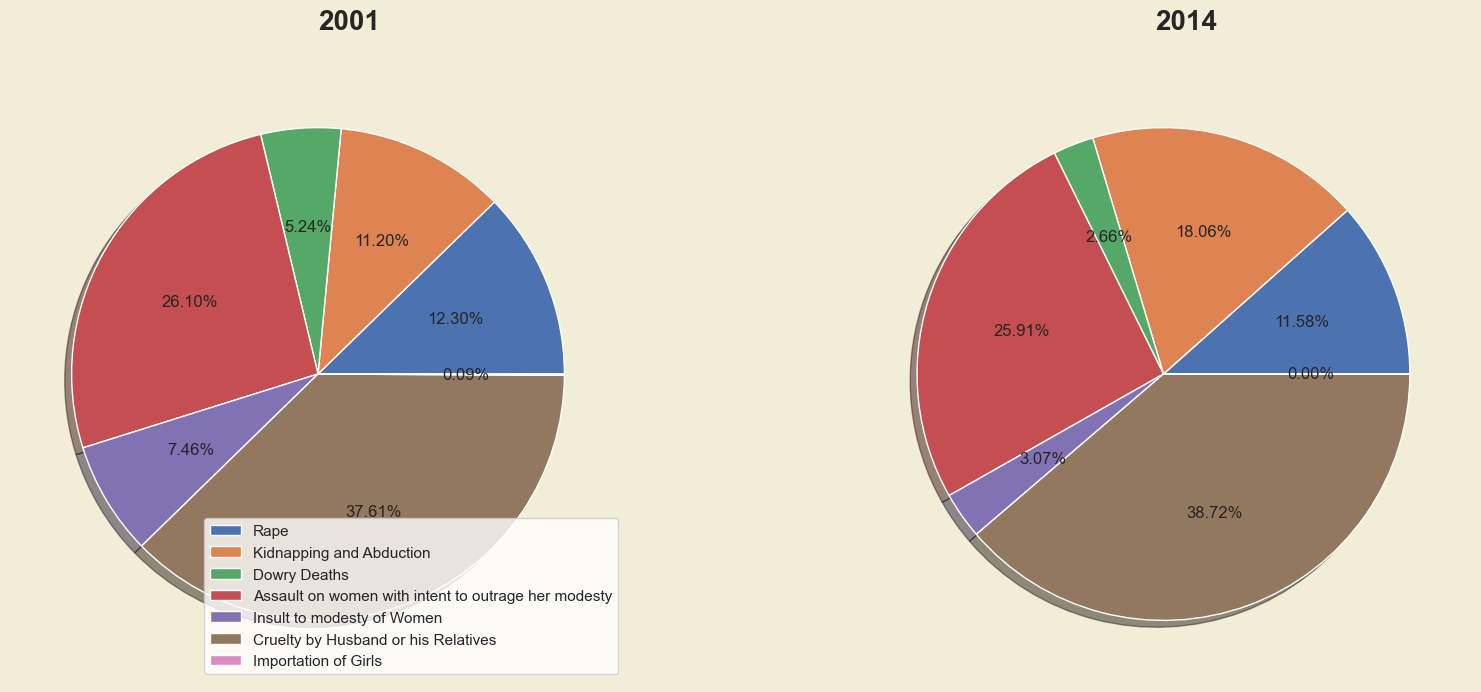

In [98]:
df_2001=df1.loc[df1.index==2001]
df_2014=df1.loc[df1.index==2014]

df_2001=df_2001.drop(["total_crimes"],axis=1)
df_2014=df_2014.drop(["total_crimes"],axis=1)
crimes_in_2001=list(df_2001.iloc[0])
crimes_in_2014=list(df_2014.iloc[0])

f,ax=plt.subplots(1,2,figsize=(20,8))
f.patch.set_facecolor('#F2EDD7FF')
#Setting background and foreground color
for j in range(0,2):
    ax[j].set_facecolor('#F2EDD7FF')
    
ax[0].pie(crimes_in_2001,autopct='%1.2f%%',shadow=True)
ax[0].text(0,1.4,"2001",fontweight='bold',fontsize=20)
ax[1].pie(crimes_in_2014,autopct='%1.2f%%',shadow=True)
ax[0].text(3.4,1.4,"2014",fontweight='bold',fontsize=20)
ax[0].legend(labels=df_2001.columns,loc='lower right')

plt.show()

In [100]:
#state wise analysis

In [102]:
print("***** Total number of Unique States/Union Territories we have in Data *****")
print()
states=df['STATE/UT'].unique()
print("Number of states/territories without duplicates: ", len(states))
print()
print(states)

***** Total number of Unique States/Union Territories we have in Data *****

Number of states/territories without duplicates:  36

['andhrapradesh' 'arunachalpradesh' 'assam' 'bihar' 'chhattisgarh' 'goa'
 'gujarat' 'haryana' 'himachalpradesh' 'jammu&kashmir' 'jharkhand'
 'karnataka' 'kerala' 'madhyapradesh' 'maharashtra' 'manipur' 'meghalaya'
 'mizoram' 'nagaland' 'odisha' 'punjab' 'rajasthan' 'sikkim' 'tamilnadu'
 'tripura' 'uttarpradesh' 'uttarakhand' 'westbengal' 'a&nislands'
 'chandigarh' 'd&nhaveli' 'daman&diu' 'delhi' 'lakshadweep' 'puducherry'
 'telangana']


In [104]:
crimes=['Rape','Kidnapping and Abduction','Dowry Deaths',
        'Assault on women with intent to outrage her modesty',
        'Insult to modesty of Women','Cruelty by Husband or his Relatives',
        'Importation of Girls','total_crimes']

df_state=pd.DataFrame()
for i in crimes:
    df_state_crimes=df.groupby(['STATE/UT'])[i].sum()
    df_state[i]=df_state_crimes

print("***** Each cateogry of crimes in each state from 2001 to 2014 *****")
print()
df_state=df_state.sort_values(by='total_crimes',ascending=False)
df_state.reset_index()


***** Each cateogry of crimes in each state from 2001 to 2014 *****



,STATE/UT,Rape,Kidnapping and Abduction,Dowry Deaths,Assault on women with intent to outrage her modesty,Insult to modesty of Women,Cruelty by Husband or his Relatives,Importation of Girls,total_crimes
0,uttarpradesh,51150,135906,57256,91212,53130,193738,6,582398
1,andhrapradesh,32150,34504,13844,126952,86964,280906,34,575354
2,westbengal,47876,61158,12308,66908,5348,344124,254,537976
3,rajasthan,45684,66278,11854,83362,794,262200,14,470186
4,madhyapradesh,90996,35608,21090,195478,20964,102816,134,467086
5,maharashtra,48974,30368,9696,114704,32634,193202,6,429584
6,assam,40190,62074,3268,38256,254,115300,22,259364
7,kerala,20030,4452,700,80438,7930,111626,0,225176
8,gujarat,11644,34670,1108,23186,3230,146468,0,220306
9,bihar,30758,57086,32206,16958,694,69770,904,208376


In [106]:
def without_hue_state(data,feature,ax):
    
    total=data['total_crimes'].sum()
    bars_plot=ax.patches
    
    for bars in bars_plot:
        percentage = '{:.1f}%'.format(100 * bars.get_height()/total)
        x = bars.get_x() + bars.get_width()/2.0
        y = bars.get_height()
        ax.text(x, y,percentage,ha='center',fontweight='bold',fontsize=10)


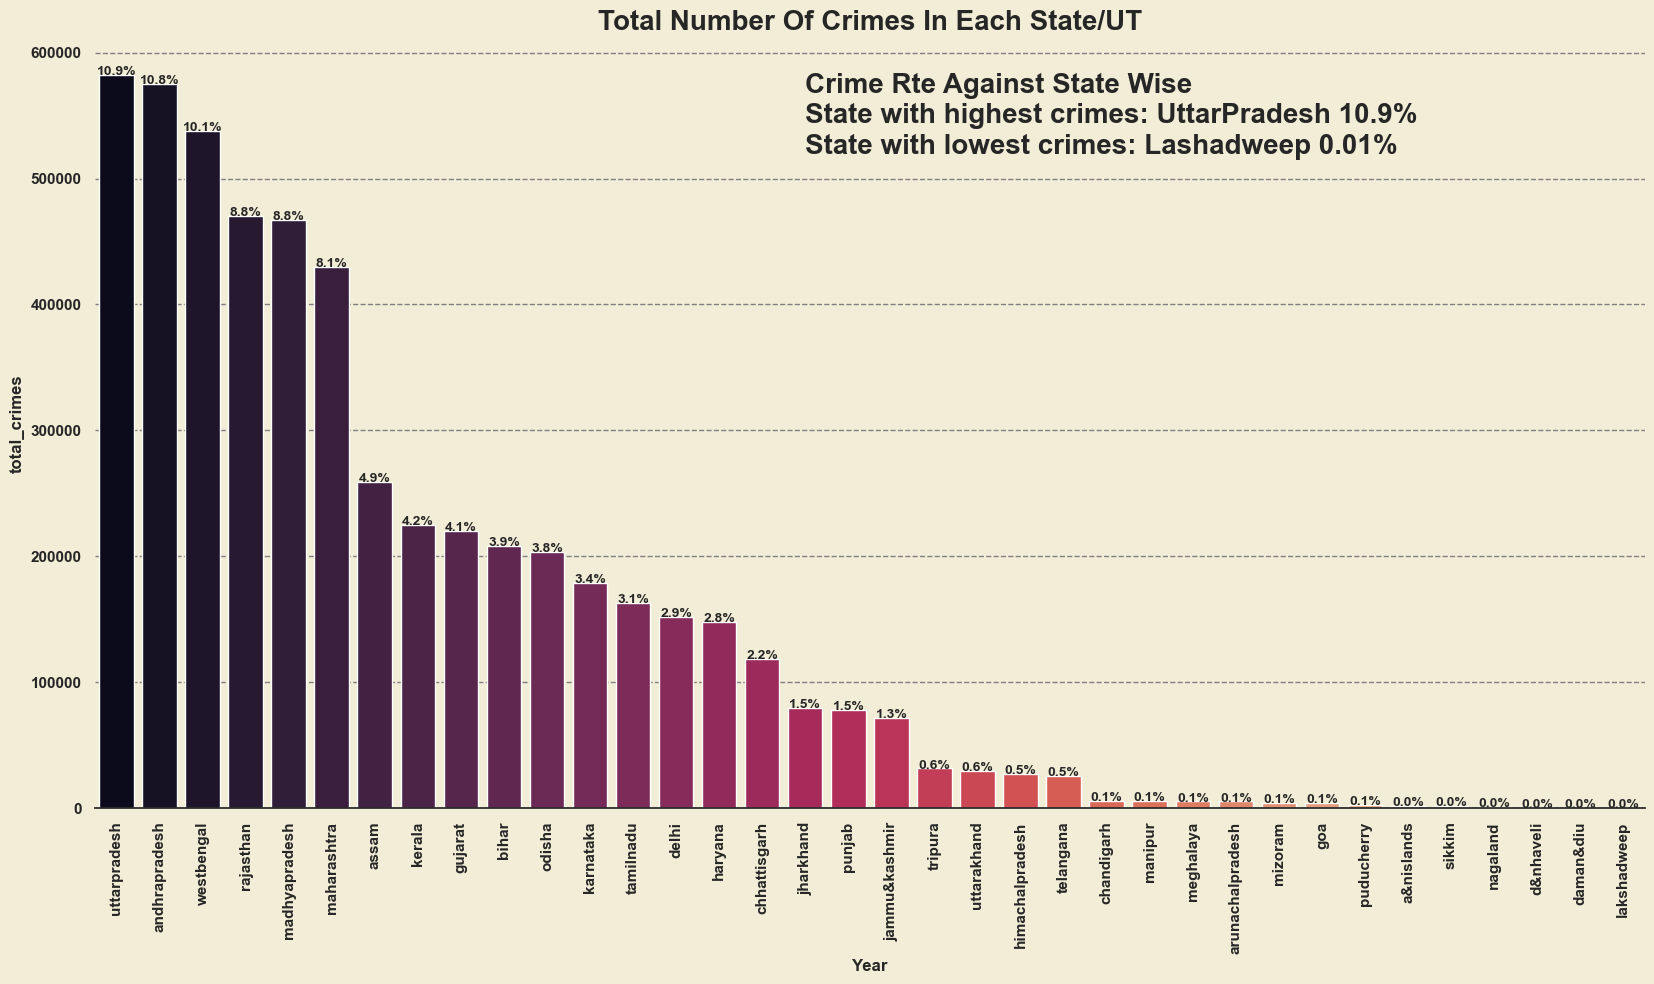

In [108]:
sns.set_theme(style='white',context='notebook')

fig=plt.figure(figsize=(20,10))

ax=plt.axes()
ax.set_facecolor("#F2EDD7FF")
fig.patch.set_facecolor("#F2EDD7FF")

ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(linestyle="--",axis="y",color='gray')

a=sns.barplot(data=df_state,x=df_state.index,y='total_crimes',palette='rocket')

ax.set_xticklabels(ax.get_xticklabels(),rotation = 90)
plt.text(16,520000,"Crime Rte Against State Wise\nState with highest crimes: UttarPradesh 10.9%\nState with lowest crimes: Lashadweep 0.01%",fontweight='bold',fontsize=20)
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
plt.xlabel("Year",fontweight='bold')
plt.ylabel("total_crimes",fontweight='bold')
plt.title("Total Number Of Crimes In Each State/UT",fontweight='bold',fontsize=20)
without_hue_state(df_state,'total_crimes',a)
plt.show()

In [ ]:
#(TOP 5 STATES/UT WITH HIGHEST CRIME RATES 2001 to 2014
Uttar Pradesh
Andhra Pradesh
West Bengal
Rajasthan
Madhya Pradesh)

In [112]:
df_state.head()

,Rape,Kidnapping and Abduction,Dowry Deaths,Assault on women with intent to outrage her modesty,Insult to modesty of Women,Cruelty by Husband or his Relatives,Importation of Girls,total_crimes
STATE/UT,,,,,,,,
uttarpradesh,51150,135906,57256,91212,53130,193738,6,582398
andhrapradesh,32150,34504,13844,126952,86964,280906,34,575354
westbengal,47876,61158,12308,66908,5348,344124,254,537976
rajasthan,45684,66278,11854,83362,794,262200,14,470186
madhyapradesh,90996,35608,21090,195478,20964,102816,134,467086


In [ ]:
FIVE STATES/UT WITH LEAST CRIME RATES 2001 to 2014
Sikkim
Nagaland
d&nhaveli
daman&diu
lakshadweep

In [114]:
df_state.tail()

,Rape,Kidnapping and Abduction,Dowry Deaths,Assault on women with intent to outrage her modesty,Insult to modesty of Women,Cruelty by Husband or his Relatives,Importation of Girls,total_crimes
STATE/UT,,,,,,,,
sikkim,570,180,4,586,34,108,0,1482
nagaland,562,190,2,260,24,32,2,1072
d&nhaveli,132,224,2,106,12,90,0,566
daman&diu,60,44,6,40,4,76,0,230
lakshadweep,20,2,0,14,4,14,0,54


In [ ]:
States with lees crime rate

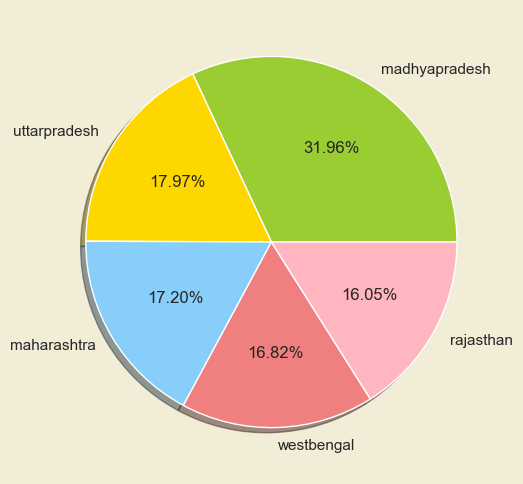

In [122]:
df_state_rape=df_state.sort_values(by="Rape",ascending=False)
df_highr=df_state_rape.iloc[:,0:1].head()
df_highr.reset_index(inplace=True)
fig=plt.figure(figsize=(20,5))

ax=plt.axes()
ax.set_facecolor("#F2EDD7FF")
fig.patch.set_facecolor("#F2EDD7FF")


plt.pie(df_highr["Rape"],colors=colors,labels=df_highr['STATE/UT'],autopct='%1.2f%%',shadow=True)
plt.tight_layout()
plt.show()
#df_state_rape[df_state_rape.index,df_state_rape['Rape']].head()






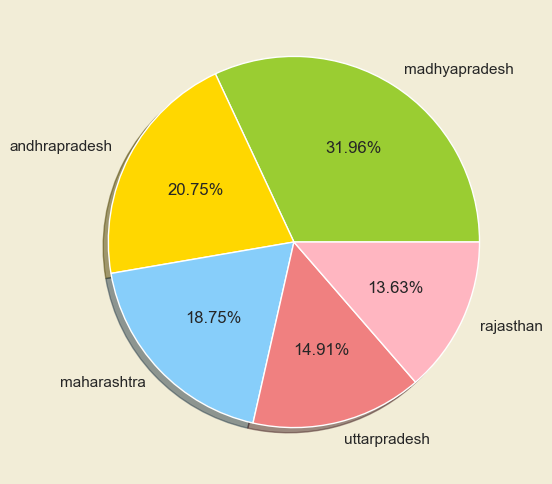

In [124]:
df_state_assault=df_state.sort_values(by='Assault on women with intent to outrage her modesty',ascending=False)
df_higha=df_state_assault.iloc[:,[3]].head()


fig=plt.figure(figsize=(20,5))

ax=plt.axes()
ax.set_facecolor("#F2EDD7FF")
fig.patch.set_facecolor("#F2EDD7FF")


plt.pie(df_higha['Assault on women with intent to outrage her modesty'],colors=colors,labels=df_higha.index,autopct='%1.2f%%',shadow=True)
plt.tight_layout()
plt.show()


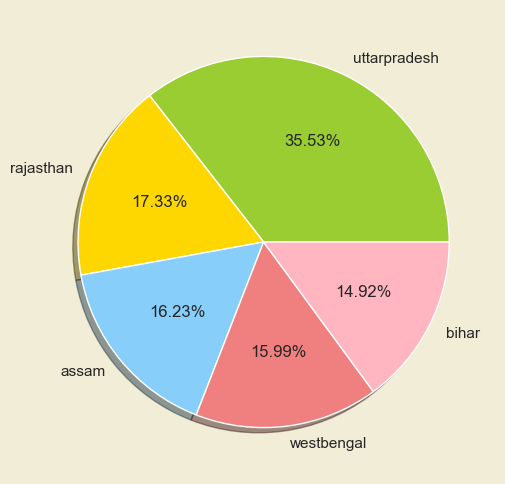

In [126]:
df_state_kidnapping=df_state.sort_values(by='Kidnapping and Abduction',ascending=False)
df_highk=df_state_kidnapping.iloc[:,[1]].head()


fig=plt.figure(figsize=(20,5))

ax=plt.axes()
ax.set_facecolor("#F2EDD7FF")
fig.patch.set_facecolor("#F2EDD7FF")


plt.pie(df_highk["Kidnapping and Abduction"],colors=colors,labels=df_highk.index,autopct='%1.2f%%',shadow=True)
plt.tight_layout()
plt.show()


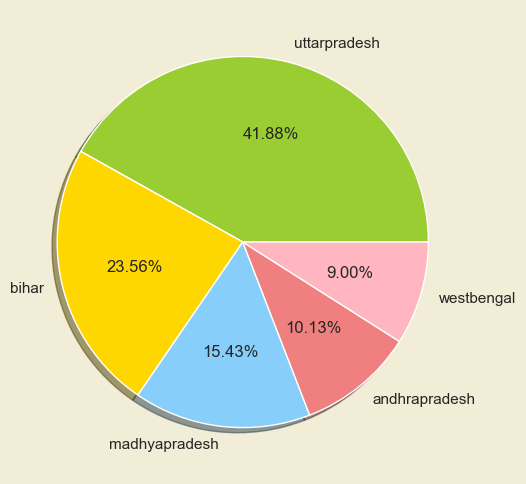

In [128]:
df_state_kidnapping=df_state.sort_values(by='Dowry Deaths',ascending=False)
df_highk=df_state_kidnapping.iloc[:,[2]].head()


fig=plt.figure(figsize=(20,5))

ax=plt.axes()
ax.set_facecolor("#F2EDD7FF")
fig.patch.set_facecolor("#F2EDD7FF")


plt.pie(df_highk["Dowry Deaths"],colors=colors,labels=df_highk.index,autopct='%1.2f%%',shadow=True)
plt.tight_layout()
plt.show()


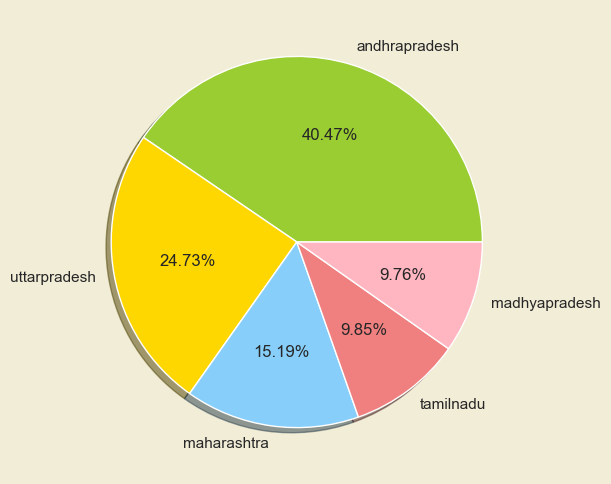

In [130]:
df_state_kidnapping=df_state.sort_values(by='Insult to modesty of Women',ascending=False)
df_highk=df_state_kidnapping.iloc[:,[4]].head()


fig=plt.figure(figsize=(20,5))

ax=plt.axes()
ax.set_facecolor("#F2EDD7FF")
fig.patch.set_facecolor("#F2EDD7FF")


plt.pie(df_highk['Insult to modesty of Women'],colors=colors,labels=df_highk.index,autopct='%1.2f%%',shadow=True)
plt.tight_layout()
plt.show()


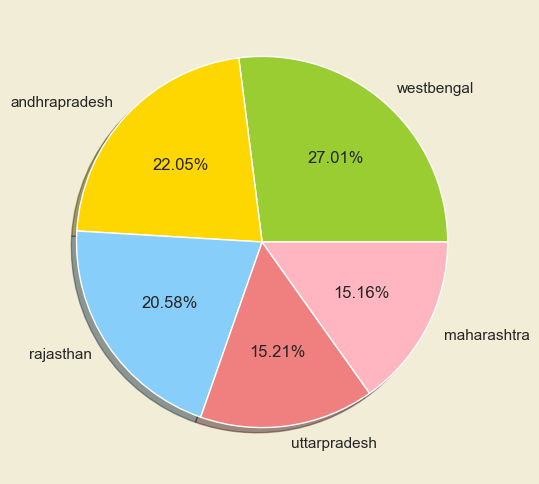

In [132]:
df_state_kidnapping=df_state.sort_values(by='Cruelty by Husband or his Relatives',ascending=False)
df_highk=df_state_kidnapping.iloc[:,[5]].head()


fig=plt.figure(figsize=(20,5))

ax=plt.axes()
ax.set_facecolor("#F2EDD7FF")
fig.patch.set_facecolor("#F2EDD7FF")


plt.pie(df_highk['Cruelty by Husband or his Relatives'],colors=colors,labels=df_highk.index,autopct='%1.2f%%',shadow=True)
plt.tight_layout()
plt.show()


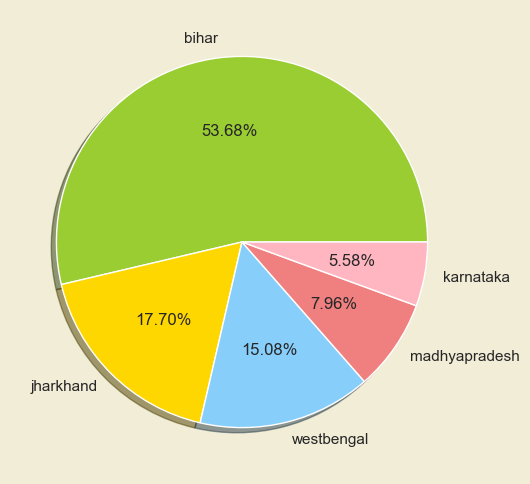

In [134]:
df_state_kidnapping=df_state.sort_values(by='Importation of Girls',ascending=False)
df_highk=df_state_kidnapping.iloc[:,[6]].head()


fig=plt.figure(figsize=(20,5))

ax=plt.axes()
ax.set_facecolor("#F2EDD7FF")
fig.patch.set_facecolor("#F2EDD7FF")


plt.pie(df_highk['Importation of Girls'],colors=colors,labels=df_highk.index,autopct='%1.2f%%',shadow=True)
plt.tight_layout()
plt.show()
